# Missing Values and Feature Types Analysis

This notebook analyses missing values and feature types in the Home Credit application training dataset.

The objective is to understand which variables require imputation, which variables are categorical, and what preprocessing steps are needed before building the baseline Probability of Default model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
app_train = pd.read_csv("../data/raw/application_train.csv")

app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
app_train.shape

(307511, 122)

The dataset shape shows the number of applicant records and the number of available variables before preprocessing.

In [4]:
target = "TARGET"

app_train[target].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

The target variable is imbalanced because most applicants did not face repayment difficulty, while a smaller percentage did. This is common in credit risk modelling.

In [5]:
missing_values = app_train.isnull().sum()
missing_percentage = app_train.isnull().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
}).sort_values("Missing Percentage", ascending=False)

missing_summary.head(30)

,Missing Values,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [6]:
columns_with_missing = missing_summary[missing_summary["Missing Values"] > 0]

columns_with_missing.shape

(67, 2)

In [7]:
high_missing_columns = missing_summary[missing_summary["Missing Percentage"] > 40]

high_missing_columns

,Missing Values,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


Columns with very high missing values may need special treatment. In a real credit risk project, these columns may be dropped, imputed carefully, or converted into missing-value indicators depending on business relevance.

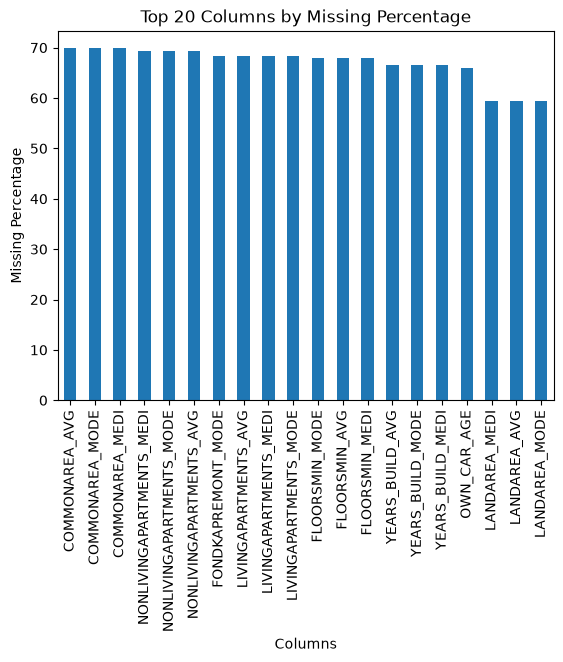

In [8]:
missing_summary.head(20)["Missing Percentage"].plot(kind="bar")

plt.title("Top 20 Columns by Missing Percentage")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")
plt.show()

In [9]:

numeric_columns = app_train.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = app_train.select_dtypes(include=["object"]).columns

print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 106
Number of categorical columns: 16


C:\Users\gsard\AppData\Local\Temp\ipykernel_33824\1572546829.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = app_train.select_dtypes(include=["object"]).columns


In [10]:
categorical_columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')

In [11]:
numeric_columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=106)

In [12]:
categorical_summary = pd.DataFrame({
    "Column": categorical_columns,
    "Unique Values": [app_train[col].nunique() for col in categorical_columns],
    "Missing Percentage": [app_train[col].isnull().mean() * 100 for col in categorical_columns]
}).sort_values("Unique Values", ascending=False)

categorical_summary

,Column,Unique Values,Missing Percentage
11,ORGANIZATION_TYPE,58,0.000000
9,OCCUPATION_TYPE,18,31.345545
5,NAME_INCOME_TYPE,8,0.000000
4,NAME_TYPE_SUITE,7,0.420148
14,WALLSMATERIAL_MODE,7,50.840783
10,WEEKDAY_APPR_PROCESS_START,7,0.000000
7,NAME_FAMILY_STATUS,6,0.000000
8,NAME_HOUSING_TYPE,6,0.000000
6,NAME_EDUCATION_TYPE,5,0.000000
12,FONDKAPREMONT_MODE,4,68.386172


Categorical variables must be converted into numerical format before modelling. This is usually done through one-hot encoding.

In [13]:
numeric_missing_summary = missing_summary.loc[numeric_columns].sort_values("Missing Percentage", ascending=False)

numeric_missing_summary.head(20)

,Missing Values,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
FLOORSMIN_AVG,208642,67.848630


Numerical variables with missing values will require imputation before model training. A common baseline approach is median imputation.

In [14]:
X = app_train.drop(columns=[target])
y = app_train[target]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (307511, 121)
Target data shape: (307511,)


In [15]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 105
Categorical features: 16


C:\Users\gsard\AppData\Local\Temp\ipykernel_33824\346851995.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


## Preprocessing Plan

Before building the baseline Probability of Default model, the following preprocessing steps are required:

1. Separate the target variable from the feature variables.
2. Identify numerical and categorical variables.
3. Fill missing numerical values using median imputation.
4. Fill missing categorical values using the most frequent category.
5. Convert categorical variables into numerical format using one-hot encoding.
6. Scale numerical variables for logistic regression.
7. Split the data into training and testing sets.

This preprocessing plan will be implemented in the baseline modelling notebook.

## Business Observations

The Home Credit dataset contains both numerical and categorical applicant-level variables.

Several variables have missing values, which is common in real-world lending datasets because applicants may not provide all information or some data may not be available.

Missing value treatment is important because machine learning models cannot directly handle missing values.

Categorical variables such as contract type, gender, education type, family status, and occupation type must be encoded before modelling.

The next step is to build a baseline Probability of Default model using a preprocessing pipeline.